# Analyse et Traitement des Données d'Élévation GMTED2010

Ce notebook combine :
- Le découpage du raster GMTED2010 pour Algérie et Tunisie
- L'analyse exploratoire du raster d'élévation
- Le traitement avec capping 1%-99% et export

## Partie 1: Découpage du Raster d'Élévation GMTED2010

### Imports et Configuration

In [7]:
import geopandas as gpd
import rasterio
import rasterio.mask
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from rasterio.plot import show

# Configuration des graphiques
plt.rcParams['figure.dpi'] = 100
sns.set(style="whitegrid")

### 1️⃣ Chargement des Shapefiles

In [8]:
# Charger le shapefile GMTED
gmted_shp = gpd.read_file(
    r"C:\Users\Y A N I S\Desktop\set\gmted2010.shp"
)

# Charger les pays pour filtrer
world = gpd.read_file(
    r"C:\Users\Y A N I S\Desktop\set\ne_110m_admin_0_countries.shp"
)

countries = world[world["NAME"].isin(["Algeria", "Tunisia"])]

print("✅ Shapefiles chargés")

✅ Shapefiles chargés


### 2️⃣ Reprojection et Clipping

In [9]:
# Reprojeter les pays dans le CRS du GMTED
countries = countries.to_crs(gmted_shp.crs)

# Clip le shapefile GMTED avec Algérie + Tunisie
gmted_clipped = gpd.clip(gmted_shp, countries)

print(f"✅ GMTED clippé : {len(gmted_clipped)} polygones")

✅ GMTED clippé : 1 polygones


### 3️⃣ Chargement et Découpage du Raster

In [10]:
raster_path = r"C:\Users\Y A N I S\Desktop\set\mn30_grd\w001001.adf"

with rasterio.open(raster_path) as src:
    print(f"✅ Raster chargé : {src.width}x{src.height} pixels")
    
    # Reprojeter le shapefile clippé dans le CRS du raster
    gmted_clipped_reproj = gmted_clipped.to_crs(src.crs)
    countries_reproj = countries.to_crs(src.crs)
    
    # Extraire les géométries
    geometries = gmted_clipped_reproj.geometry.values
    
    # Appliquer le masque
    out_image, out_transform = rasterio.mask.mask(
        src, geometries, crop=True, filled=False, all_touched=True
    )
    out_meta = src.meta.copy()
    src_nodata = src.nodata

✅ Raster chargé : 43200x20880 pixels


### 4️⃣ Sauvegarde du Raster Découpé

In [11]:
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

output_path = r"C:\Users\Y A N I S\Desktop\set\output\GMTED2010_Algeria_Tunisia.tif"
with rasterio.open(output_path, "w", **out_meta) as dest:
    dest.write(out_image)

print(f"✅ Raster sauvegardé dans {output_path}")

✅ Raster sauvegardé dans C:\Users\Y A N I S\Desktop\set\output\GMTED2010_Algeria_Tunisia.tif


### 5️⃣ Affichage du Raster Découpé


📊 Élévation min : -31.0 m
📊 Élévation max : 2633.0 m
📊 Élévation moyenne : 535.8 m


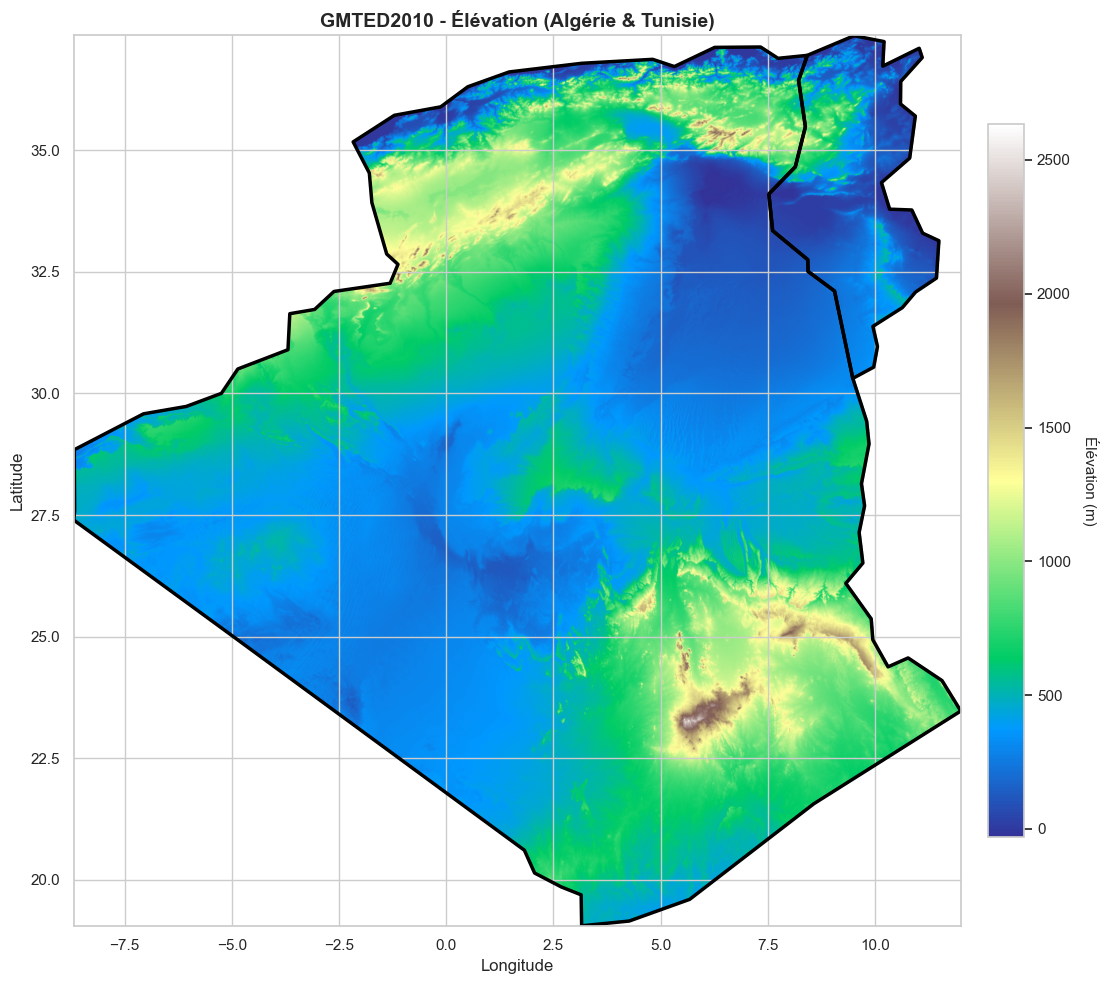

In [12]:
data = out_image[0]

if src_nodata is not None:
    data_masked = np.ma.masked_equal(data, src_nodata)
else:
    data_masked = np.ma.masked_where((data < -500) | (data > 9000), data)

print(f"\n📊 Élévation min : {data_masked.min():.1f} m")
print(f"📊 Élévation max : {data_masked.max():.1f} m")
print(f"📊 Élévation moyenne : {data_masked.mean():.1f} m")

# Affichage avec frontières
fig, ax = plt.subplots(figsize=(14, 10))

extent = [
    out_transform[2],
    out_transform[2] + out_transform[0] * out_image.shape[2],
    out_transform[5] + out_transform[4] * out_image.shape[1],
    out_transform[5]
]

im = ax.imshow(data_masked, cmap='terrain', interpolation='bilinear', extent=extent)
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Élévation (m)', rotation=270, labelpad=20, fontsize=11)

countries_reproj.boundary.plot(ax=ax, edgecolor='black', linewidth=2.5, alpha=1)

ax.set_title("GMTED2010 - Élévation (Algérie & Tunisie)", fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig(r"C:\Users\Y A N I S\Desktop\set\output\GMTED2010_elevation_with_borders.png", dpi=300, bbox_inches='tight')
plt.show()

---
## Partie 2: Analyse du Raster d'Élévation

### 1️⃣ Chargement et Préparation des Données

In [13]:
raster_path_elev = r"C:\Users\Y A N I S\Desktop\set\output\GMTED2010_Algeria_Tunisia.tif"

with rasterio.open(raster_path_elev) as src:
    data_elevation = src.read(1)
    nodata = src.nodata
    meta_elevation = src.meta.copy()
    transform_elevation = src.transform

if nodata is not None:
    data_masked_elev = np.ma.masked_equal(data_elevation, nodata)
else:
    data_masked_elev = np.ma.masked_where((data_elevation < -500) | (data_elevation > 9000), data_elevation)

df = pd.DataFrame({"elevation": data_masked_elev.flatten()})
df_valid = df.dropna(subset=['elevation']).copy()

print("\n--- Statistiques AVANT standardisation ---")
print(df_valid["elevation"].describe())


--- Statistiques AVANT standardisation ---
count    3.301396e+06
mean     5.357619e+02
std      3.256774e+02
min     -3.100000e+01
25%      3.090000e+02
50%      4.620000e+02
75%      6.970000e+02
max      2.633000e+03
Name: elevation, dtype: float64


### 2️⃣ Visualisation AVANT Transformation

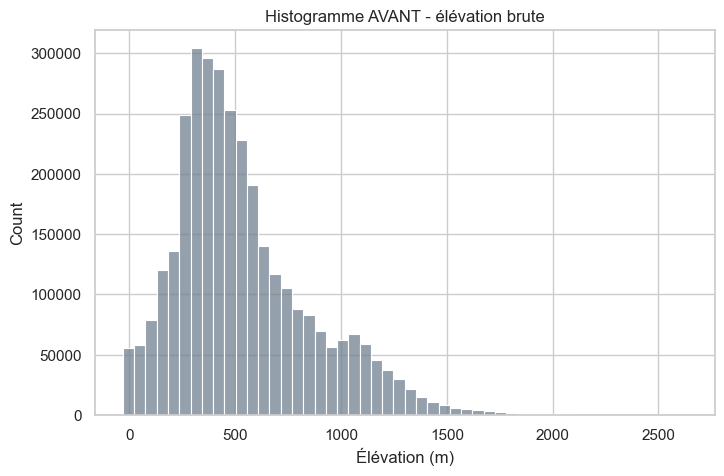

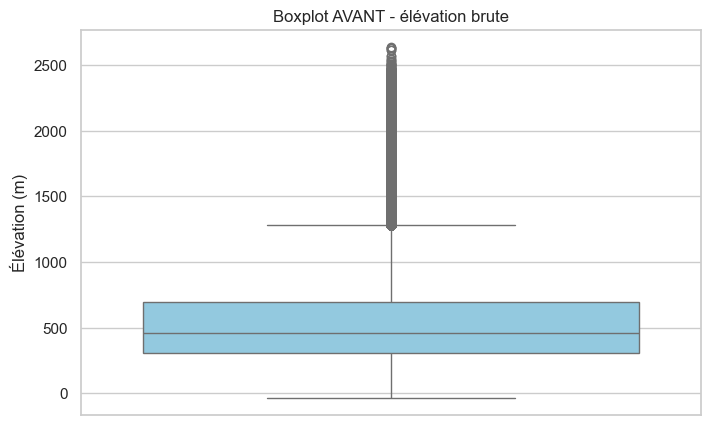

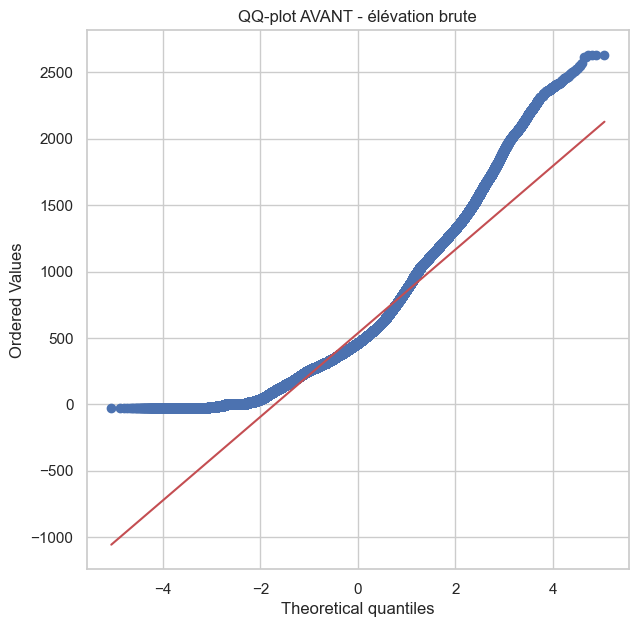

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df_valid["elevation"], bins=50, color="slategrey")
plt.title("Histogramme AVANT - élévation brute")
plt.xlabel("Élévation (m)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(y=df_valid["elevation"], color="skyblue")
plt.title("Boxplot AVANT - élévation brute")
plt.ylabel("Élévation (m)")
plt.show()

plt.figure(figsize=(7,7))
stats.probplot(df_valid["elevation"], dist="norm", plot=plt)
plt.title("QQ-plot AVANT - élévation brute")
plt.grid(True)
plt.show()

### 3️⃣ Standardisation

In [15]:
scaler_std = StandardScaler()
df_valid["elevation_std"] = scaler_std.fit_transform(df_valid[["elevation"]])

print("\n--- Statistiques APRÈS standardisation ---")
print(df_valid["elevation_std"].describe())


--- Statistiques APRÈS standardisation ---
count    3.301396e+06
mean    -2.072565e-16
std      1.000000e+00
min     -1.740256e+00
25%     -6.962777e-01
50%     -2.264876e-01
75%      4.950854e-01
max      6.439619e+00
Name: elevation_std, dtype: float64


### 4️⃣ Visualisation APRÈS Standardisation

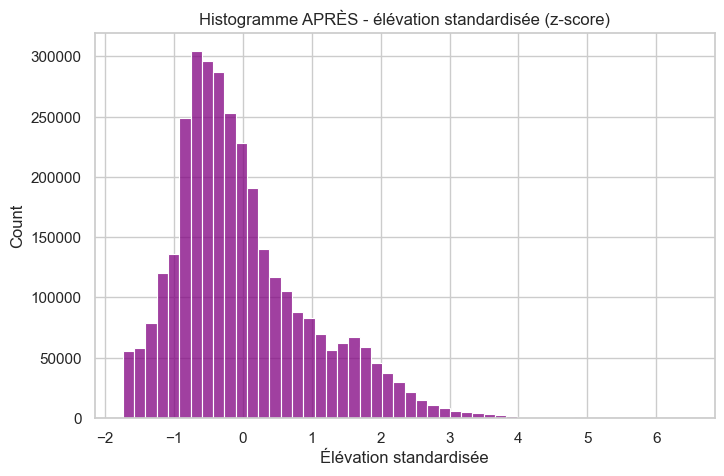

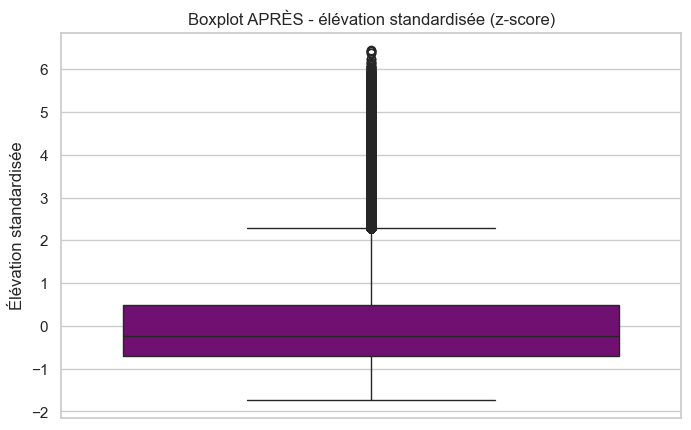

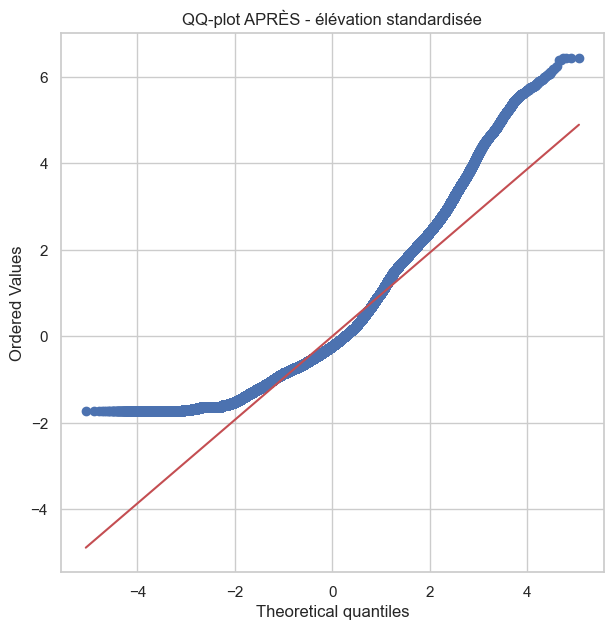

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df_valid["elevation_std"], bins=50, color="purple")
plt.title("Histogramme APRÈS - élévation standardisée (z-score)")
plt.xlabel("Élévation standardisée")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(y=df_valid["elevation_std"], color="purple")
plt.title("Boxplot APRÈS - élévation standardisée (z-score)")
plt.ylabel("Élévation standardisée")
plt.show()

plt.figure(figsize=(7,7))
stats.probplot(df_valid["elevation_std"], dist="norm", plot=plt)
plt.title("QQ-plot APRÈS - élévation standardisée")
plt.grid(True)
plt.show()

---
## Partie 3: Traitement et Export (Capping 1%-99%)

### 1️⃣ Capping 1%-99%

In [17]:
# Masquer les nodata
if nodata is not None:
    mask = (data_elevation == nodata)
else:
    mask = (data_elevation < -500) | (data_elevation > 9000)

# Valeurs valides pour percentiles
valid_values = data_elevation[~mask]

# Calcul des percentiles
q01 = np.percentile(valid_values, 1)
q99 = np.percentile(valid_values, 99)

print(f"\n--- Capping 1%-99% ---")
print(f"Percentile 1% : {q01:.2f} m")
print(f"Percentile 99% : {q99:.2f} m")

# Application du capping
data_capped = data_elevation.copy()
data_capped[~mask] = np.clip(data_elevation[~mask], q01, q99)

if nodata is not None:
    data_capped[mask] = nodata

print(f"✅ Capping appliqué")


--- Capping 1%-99% ---
Percentile 1% : 3.00 m
Percentile 99% : 1481.00 m
✅ Capping appliqué


### 2️⃣ Extraction des Coordonnées X, Y

In [18]:
# Extraction coordonnées X, Y
rows, cols = np.indices(data_capped.shape)
xs, ys = rasterio.transform.xy(transform_elevation, rows.flatten(), cols.flatten())

# DataFrame avec X, Y
df_export = pd.DataFrame({
    'X': xs,
    'Y': ys,
    'elevation': data_capped.flatten()
})

# Filtrer nodata
if nodata is not None:
    df_export = df_export[df_export['elevation'] != nodata]
else:
    df_export = df_export[(df_export['elevation'] >= -500) & (df_export['elevation'] <= 9000)]

print(f"✅ DataFrame créé avec {df_export.shape[0]} points valides")

✅ DataFrame créé avec 3301396 points valides


### 3️⃣ Export CSV

In [19]:
csv_output = r"C:\Users\Y A N I S\Desktop\set\output\elevation_capped.csv"
df_export.to_csv(csv_output, index=False, sep=';')
print(f"🎉 CSV exporté : {csv_output}")
print(f"Dimensions : {df_export.shape}")
print(df_export.head())

🎉 CSV exporté : C:\Users\Y A N I S\Desktop\set\output\elevation_capped.csv
Dimensions : (3301396, 3)
             X          Y  elevation
2184  9.512360  37.354027          3
4664  9.487360  37.345694          3
4665  9.495694  37.345694          3
4666  9.504027  37.345694          3
4667  9.512360  37.345694          3


### 4️⃣ Export Raster TIF

In [20]:
tif_output = r"C:\Users\Y A N I S\Desktop\set\output\elevation_capped.tif"
with rasterio.open(tif_output, 'w', **meta_elevation) as dst:
    dst.write(data_capped.astype(rasterio.float32), 1)

print(f"🎉 Raster cappé exporté : {tif_output}")

🎉 Raster cappé exporté : C:\Users\Y A N I S\Desktop\set\output\elevation_capped.tif


### 5️⃣ Statistiques Finales

In [21]:
print("\n--- Statistiques du raster cappé ---")
print(df_export['elevation'].describe())


--- Statistiques du raster cappé ---
count    3.301396e+06
mean     5.337744e+02
std      3.182085e+02
min      3.000000e+00
25%      3.090000e+02
50%      4.620000e+02
75%      6.970000e+02
max      1.481000e+03
Name: elevation, dtype: float64
